# Visibility Distance Prediction
**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Data Cleaning
* Exploratory data analysis
* Data Pre-Processing
* Model Training 
* Choose best model

## 1) Problem statement.

* **ATC** wants to track the weather and predict the visibility distance. To fly the planes the visibility distance is very much important, that is why this project is very much crucial.


### **What is Visibility Distance Prediction?**

* Visibility distance, that means how far any object can be seen from. Based on various climate forcasting parameters, we can predict the visibility distance with machine learning techniques.


## 2. Data Collection
- The data is collected from various sources and dumped into mongodb for our purpose. We have merged the dataset and will work on the data analysis on top of that.

### Feature Information

- **DATE** - 
- **VISIBILITY** - Distance from which can objecy can be seen.
- **DRYBULBTEMPF** - Dry bulb temperature (degrees Farenheit). Most commonly reported standard temperature. 
- **WETBULBTEMPF** - Wet bulb temperature (degrees Farenheit )
- **DewPointTempF** - Dew point temperature ( degrees Farenheit )
- **RelativeHumidity** - Relative humidity (percent )
- **WindSpeed** - Wind speed (miles per hour )
- **WindDirection** - Wind direction from true north using compass directions.
- **StationPressure** - Atmospheric pressure (inches of Mercury; or 'in Hg').
- **SeaLevelPressure** - Sea level pressure ( in Hg).
- **Precip** - Total precipitation in the past hour (in inches )

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.preprocessing import StandardScaler 
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
df =pd.read_csv('data.csv')

### top 5 record of data set


In [3]:
df.head()

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,32,31,92,0,0,29.97,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,33,32,96,0,0,29.97,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,33,32,96,0,0,29.97,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,33,32,96,0,0,29.95,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,32,31,92,0,0,29.93,29.96,0.02


**Shape of Data**

In [4]:
df.shape

(75083, 11)

### Summary of Data 

In [5]:
df.describe()

,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip
count,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000,75083.000000
mean,9.211896,55.355527,49.327544,42.424024,64.812075,11.253240,196.550751,30.005579,30.026049,0.005478
std,2.202311,17.394334,16.182867,19.577957,19.898962,6.101048,107.692804,0.235172,0.234069,0.036161
min,0.000000,1.000000,-1.000000,-19.000000,8.000000,0.000000,0.000000,28.520000,28.540000,0.000000
25%,10.000000,42.000000,36.000000,27.000000,49.000000,7.000000,110.000000,29.860000,29.880000,0.000000
50%,10.000000,56.000000,50.000000,44.000000,66.000000,10.000000,200.000000,30.000000,30.020000,0.000000
75%,10.000000,70.000000,64.000000,59.000000,82.000000,15.000000,290.000000,30.150000,30.170000,0.000000
max,14.000000,102.000000,85.000000,84.000000,100.000000,53.000000,360.000000,30.830000,30.850000,2.410000


In [6]:
df.isna().sum() 

DATE                0
VISIBILITY          0
DRYBULBTEMPF        0
WETBULBTEMPF        0
DewPointTempF       0
RelativeHumidity    0
WindSpeed           0
WindDirection       0
StationPressure     0
SeaLevelPressure    0
Precip              0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75083 entries, 0 to 75082
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DATE              75083 non-null  object 
 1   VISIBILITY        75083 non-null  float64
 2   DRYBULBTEMPF      75083 non-null  int64  
 3   WETBULBTEMPF      75083 non-null  int64  
 4   DewPointTempF     75083 non-null  int64  
 5   RelativeHumidity  75083 non-null  int64  
 6   WindSpeed         75083 non-null  int64  
 7   WindDirection     75083 non-null  int64  
 8   StationPressure   75083 non-null  float64
 9   SeaLevelPressure  75083 non-null  float64
 10  Precip            75083 non-null  float64
dtypes: float64(4), int64(6), object(1)
memory usage: 6.3+ MB


In [8]:
df['DATE'] = pd.to_datetime(df['DATE'] , format='%Y-%m-%d %H:%M:%S')
df['DATE']

0       2010-01-01 00:51:00
1       2010-01-01 01:51:00
2       2010-01-01 02:51:00
3       2010-01-01 03:51:00
4       2010-01-01 04:51:00
                ...        
75078   2018-07-27 18:51:00
75079   2018-07-27 19:51:00
75080   2018-07-27 20:51:00
75081   2018-07-27 21:51:00
75082   2018-07-27 22:51:00
Name: DATE, Length: 75083, dtype: datetime64[ns]

In [9]:
columns = [col for col in df.columns if col not in ['VISIBILITY']]
numerical_features = df[columns].select_dtypes(include=['float64', 'int64' , 'datetime64[ns]']).columns

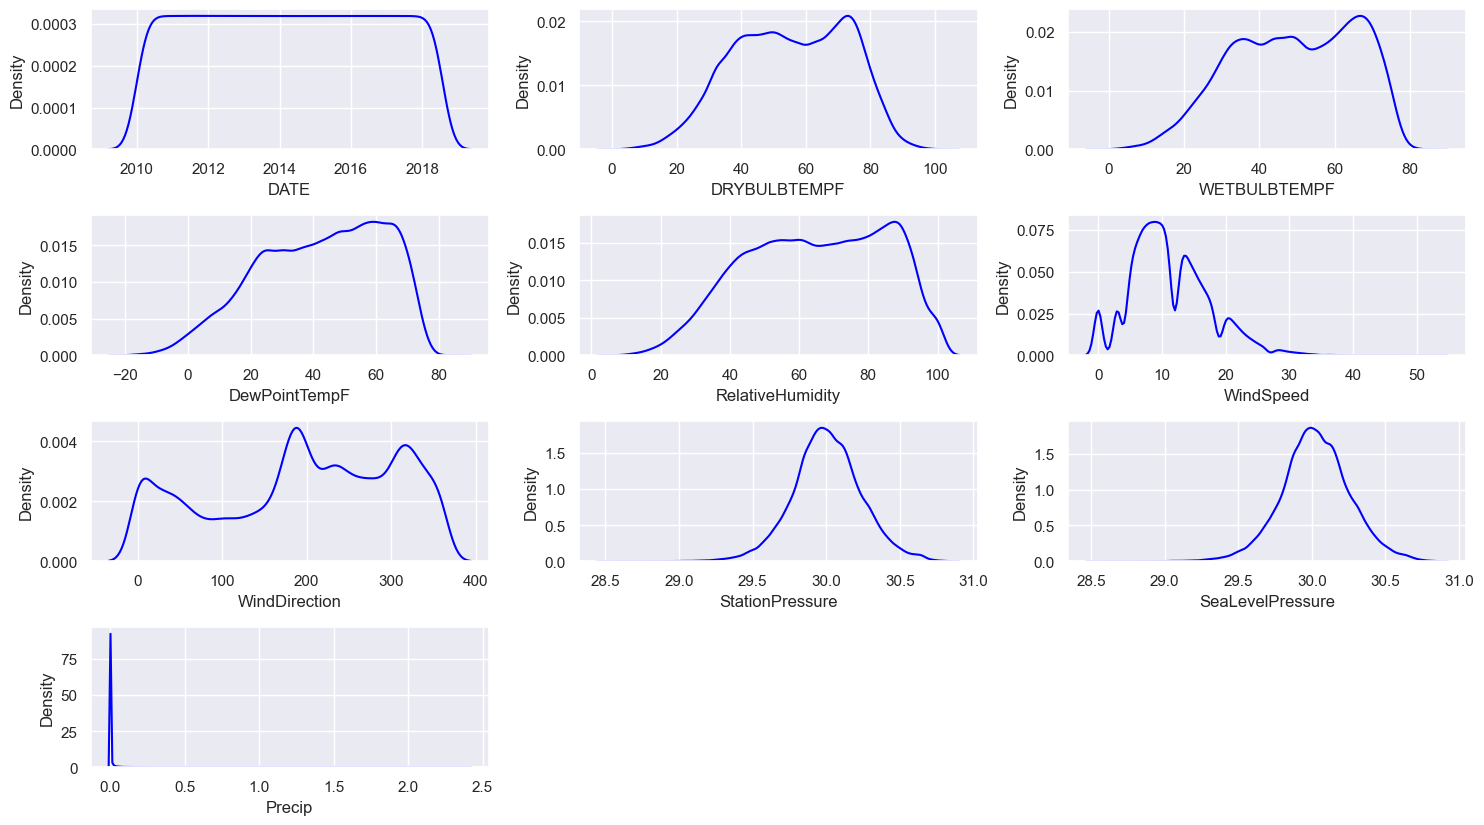

In [10]:
plt.figure(figsize=(15,10))
for i in range(len(numerical_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df[numerical_features[i]], color='blue')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()
    

In [11]:
num_features = numerical_features  # list of numerical columns
s
plt.figure(figsize=(20, 20))
count = 1
total_plots = len(num_features) ** 2  # all pairs including diagonal

for i in num_features:
    for j in num_features:
        plt.subplot(len(num_features), len(num_features), count)
        if i == j:
            # For the diagonal, show univariate KDE plots instead of bivariate
            sns.kdeplot(df[i], fill=True, color='blue')
            plt.xlabel(i)
            plt.ylabel('Density')
        else:
            sns.kdeplot(
                x=df[i], 
                y=df[j], 
                cmap="Blues", 
                fill=True, 
                bw_adjust=0.5
            )
            plt.xlabel(i)
            plt.ylabel(j)
        plt.title('{} vs {}'.format(i, j))
        count += 1

    plt.tight_layout()


NameError: name 's' is not defined

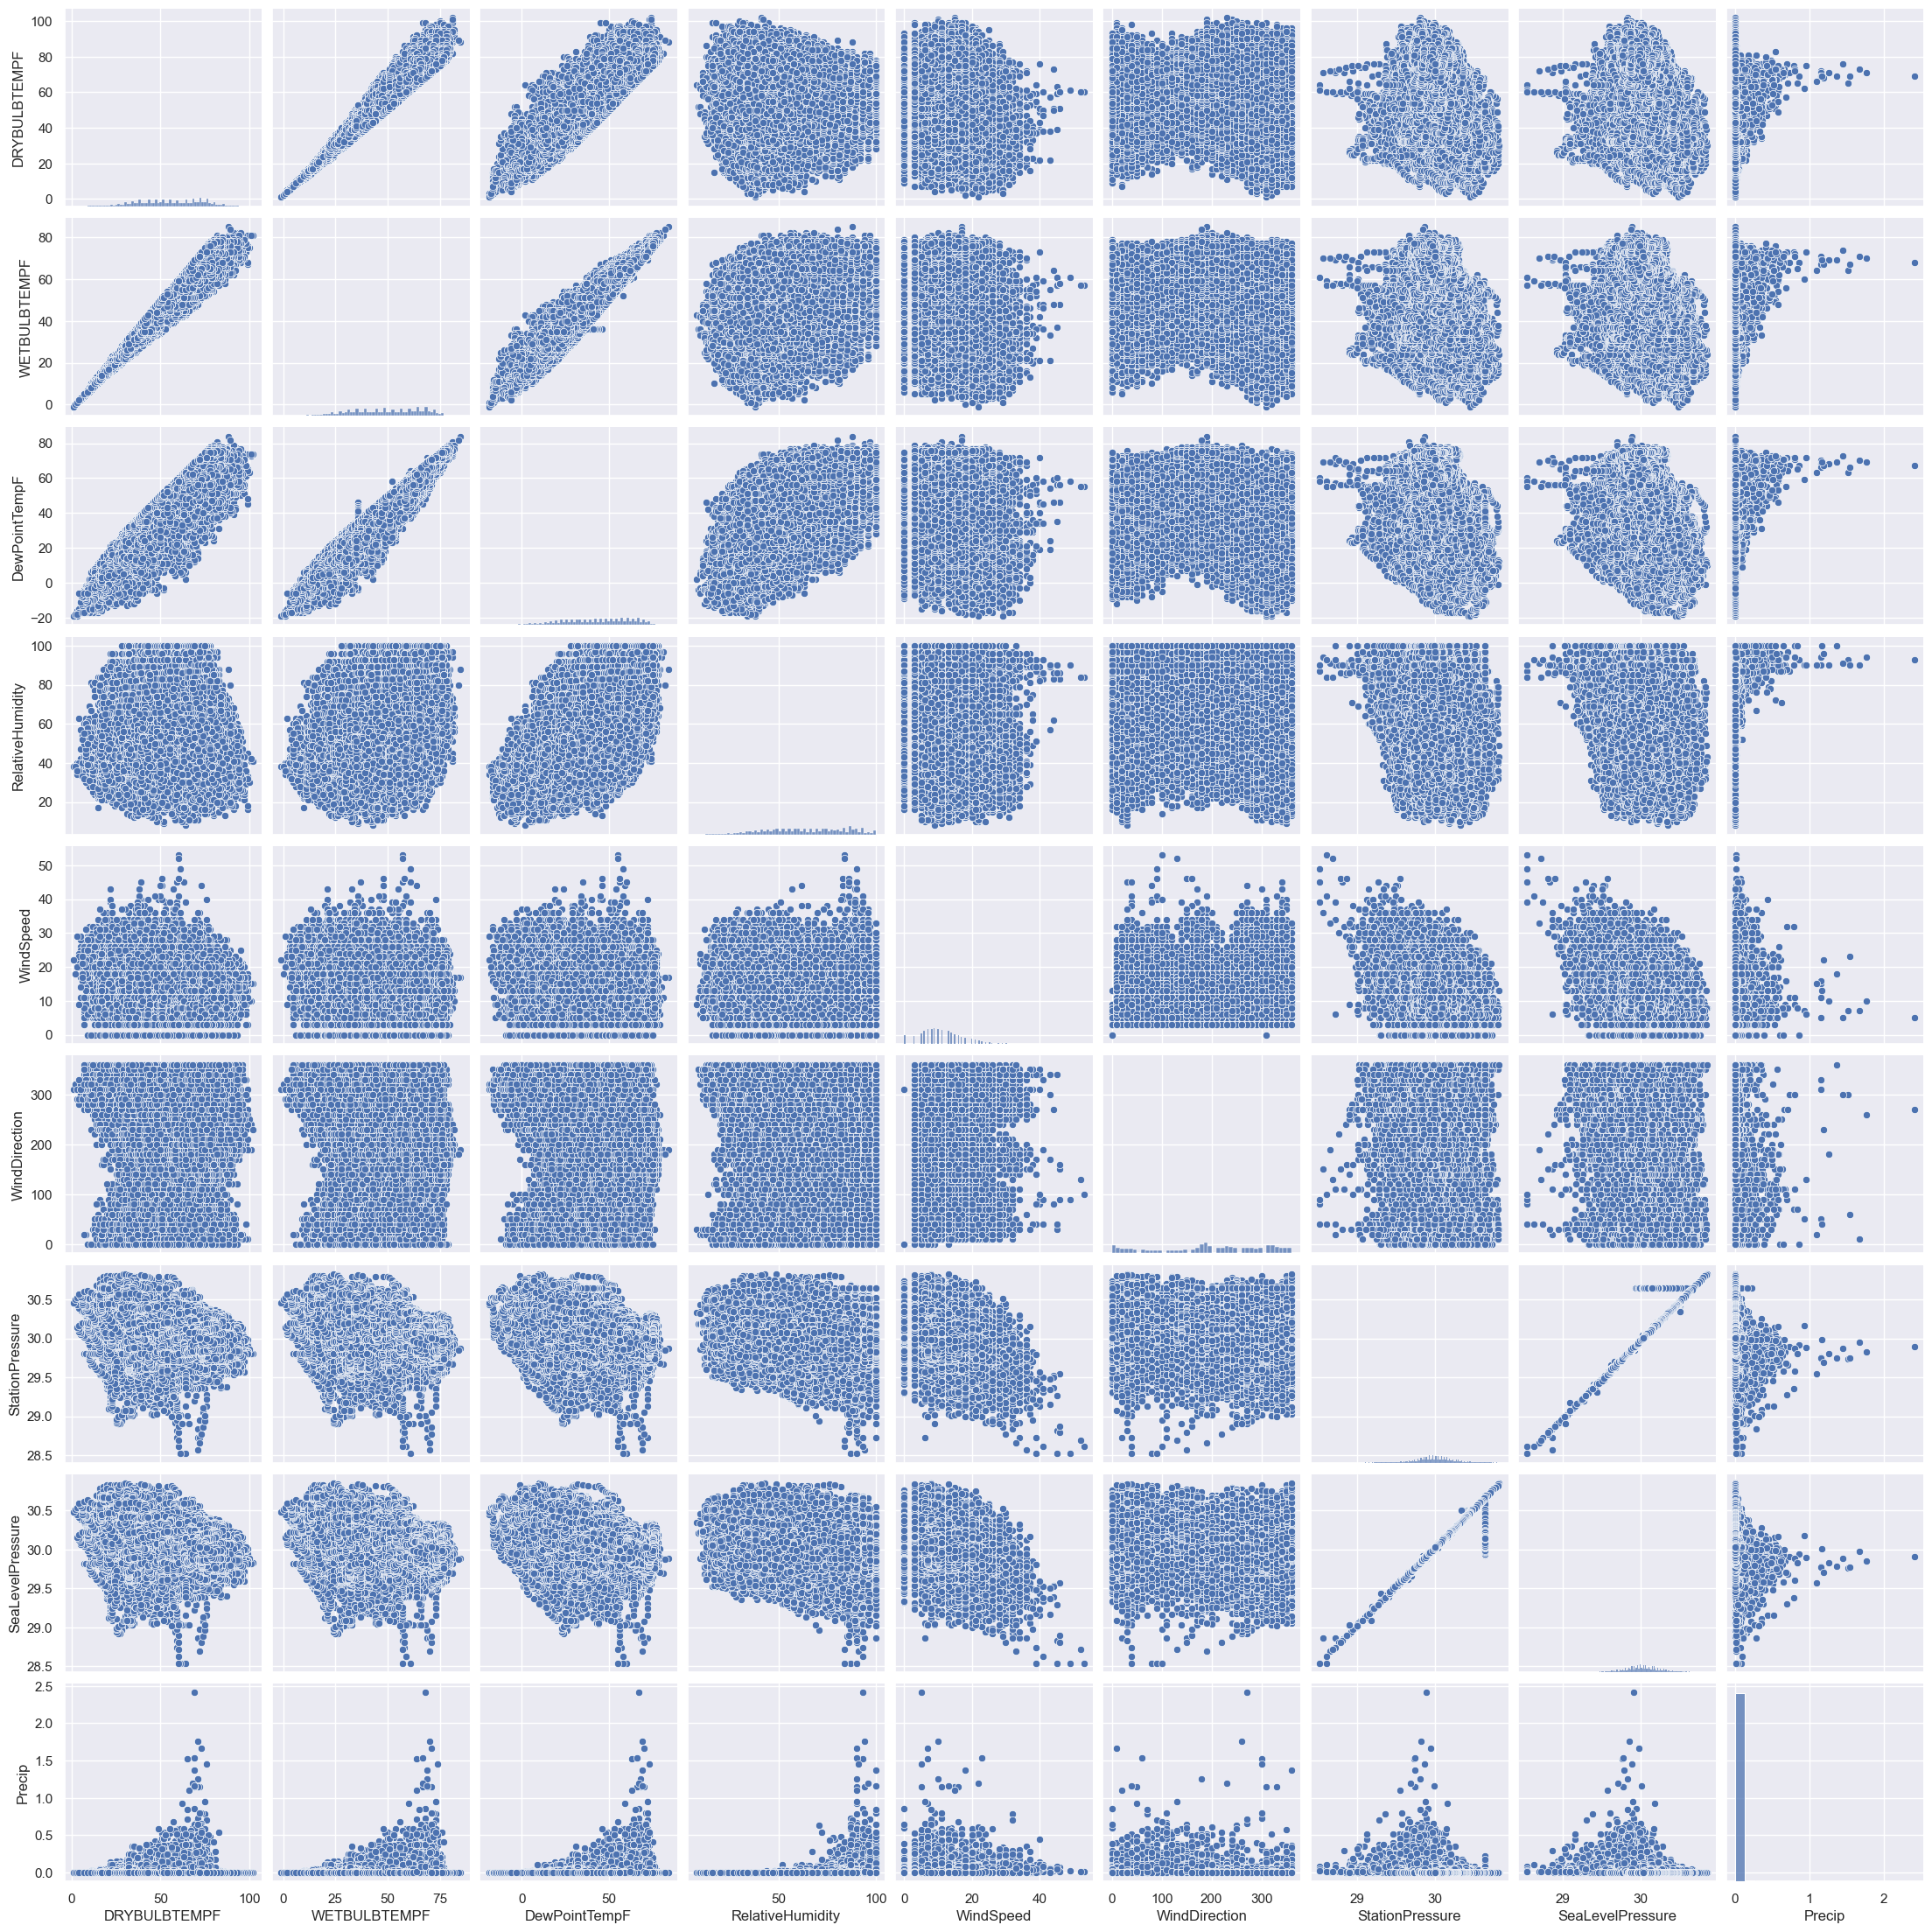

In [ ]:
sns.pairplot(df[numerical_features])

<Axes: >

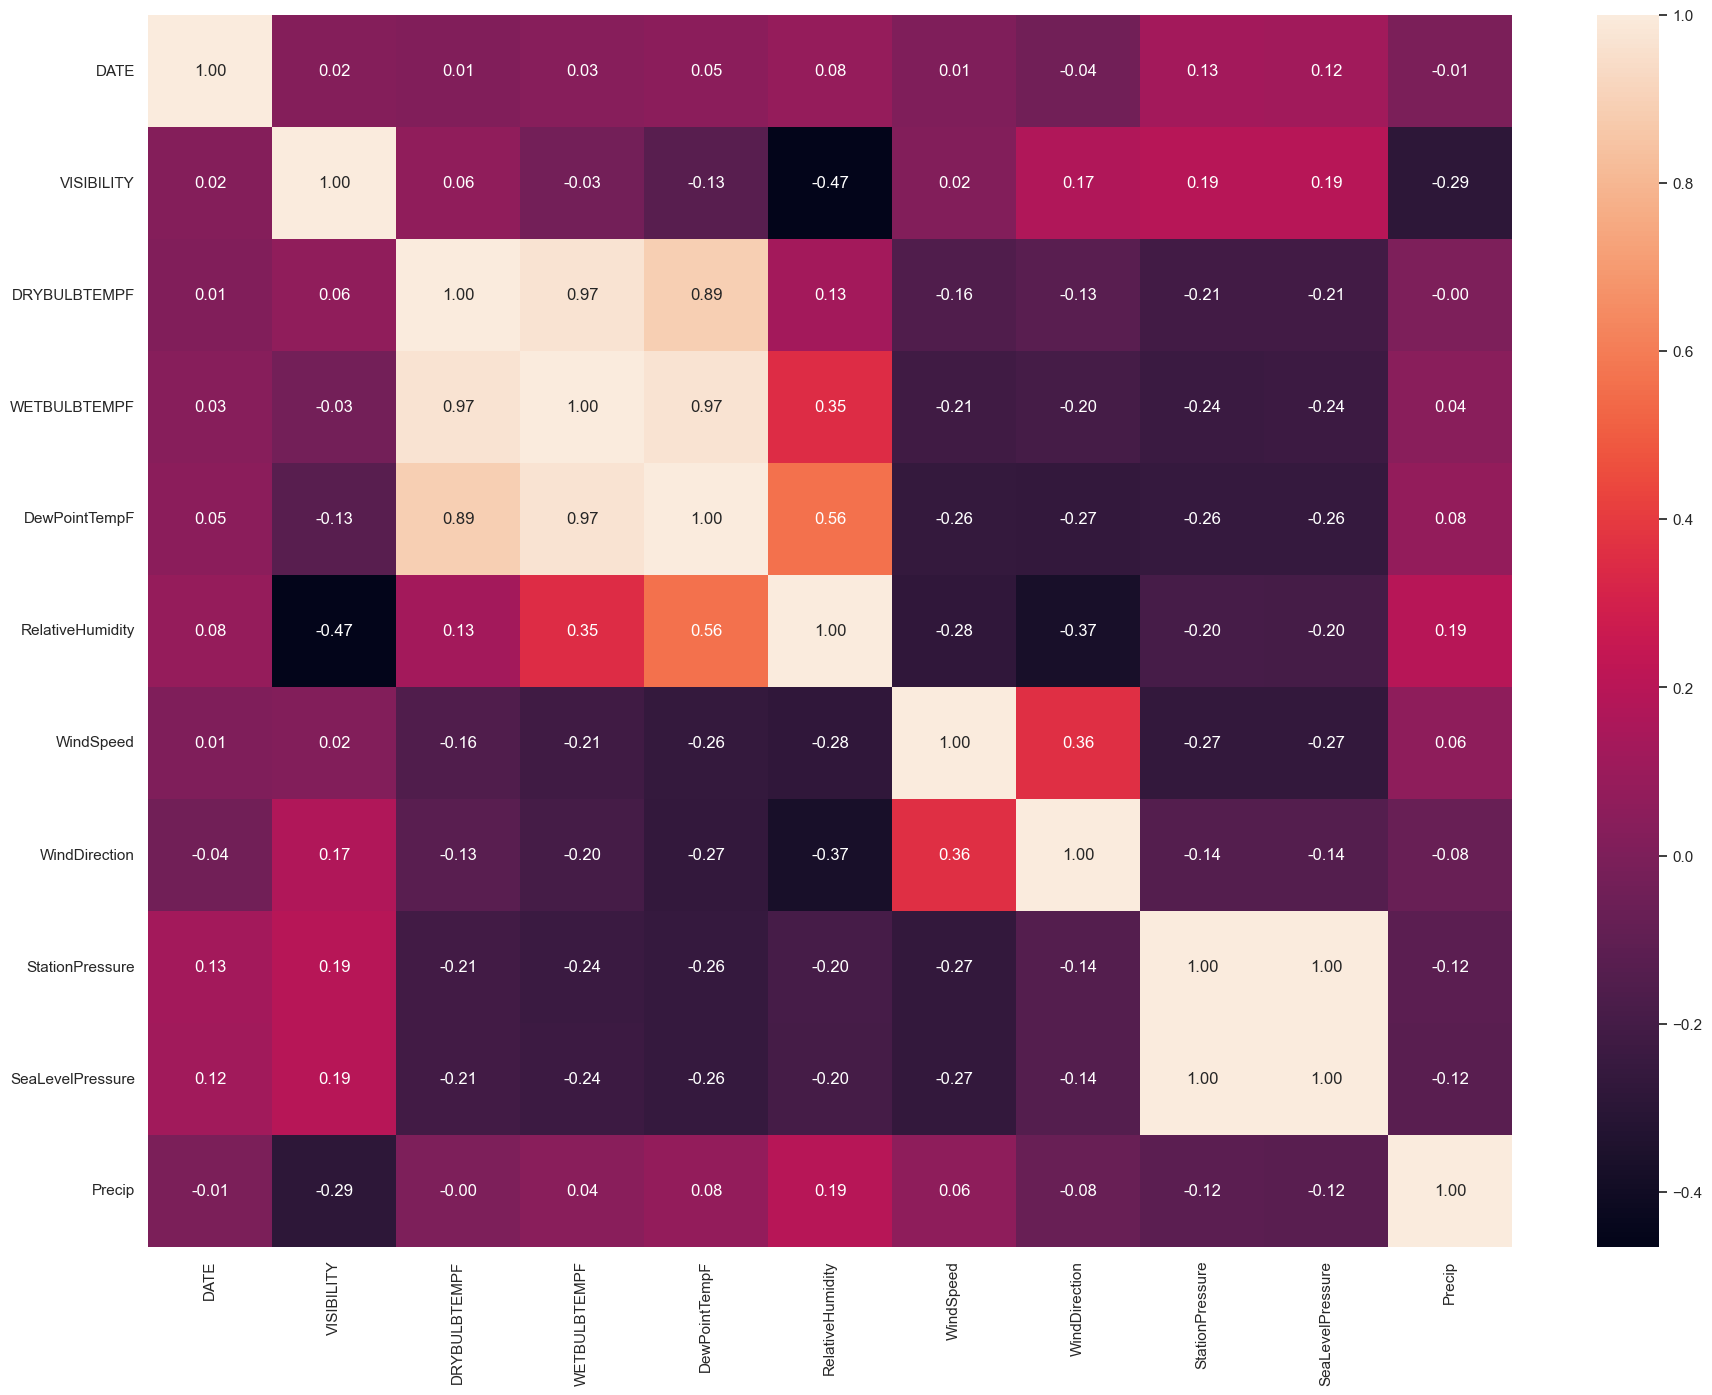

In [ ]:
plt.figure(figsize=(22,16))
sns.heatmap(df.corr(), annot=True, fmt=".2f")

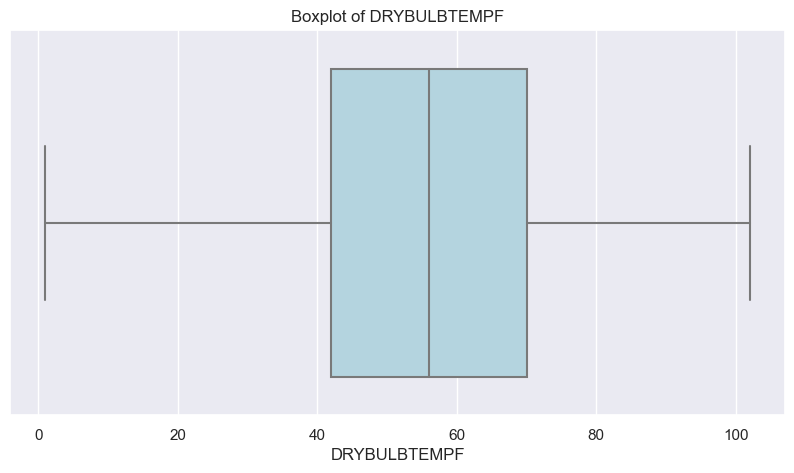

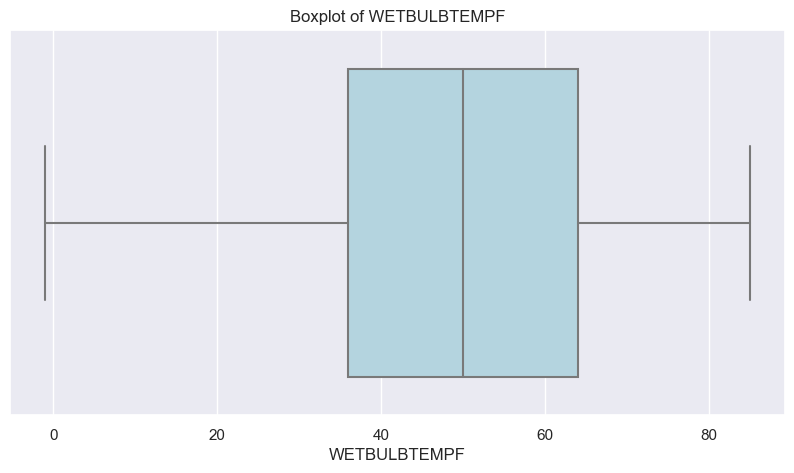

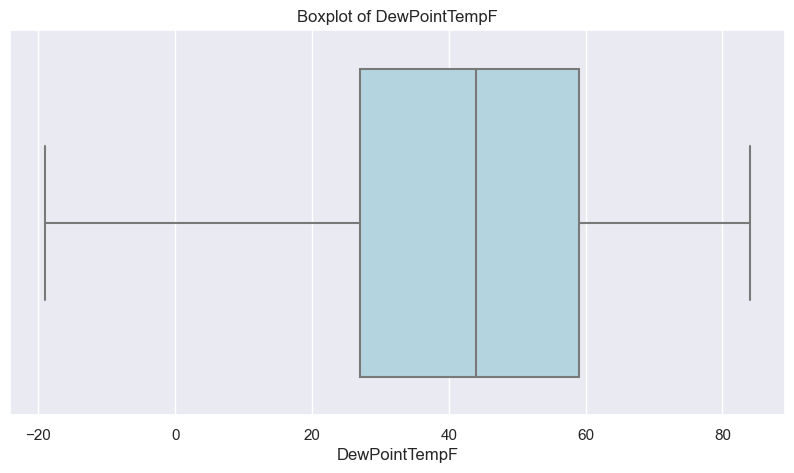

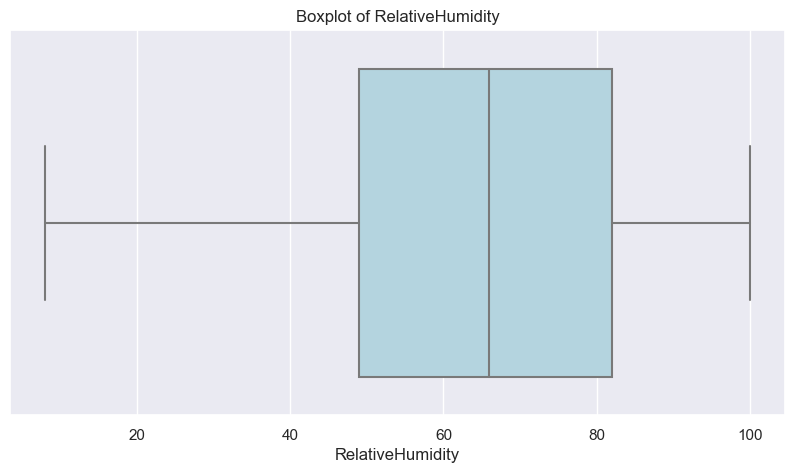

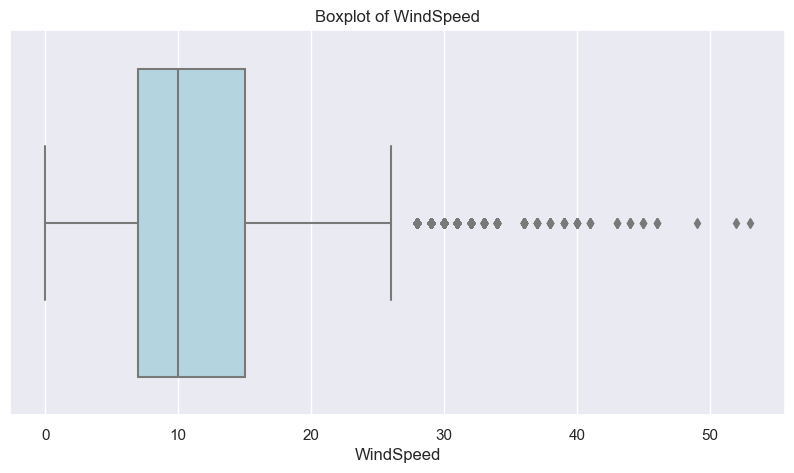

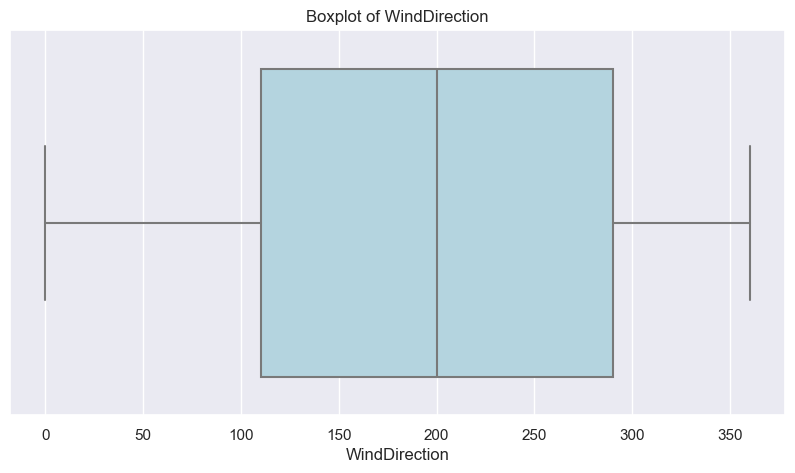

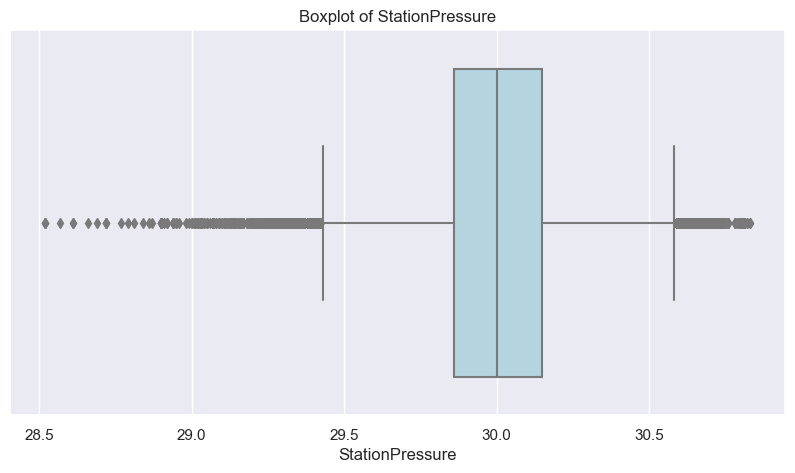

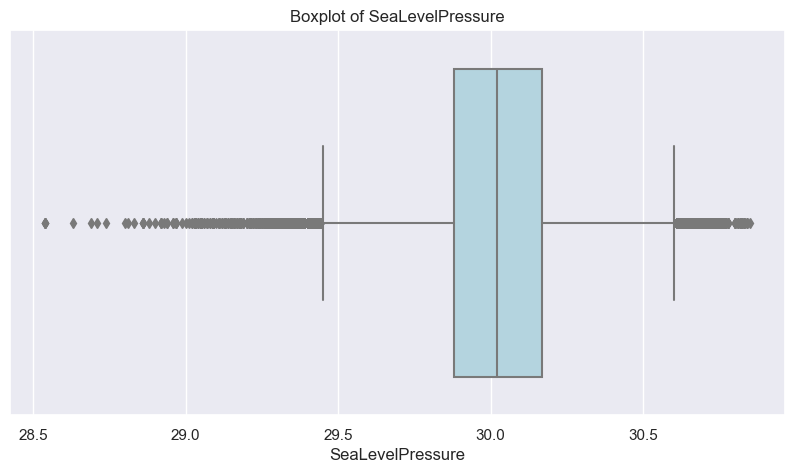

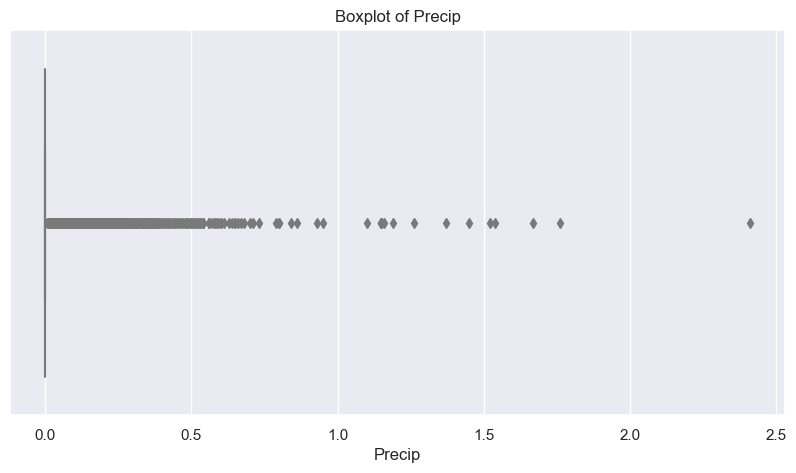

In [13]:
for i in numerical_features.drop('DATE'):
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[i], color='lightblue')
    plt.title(f'Boxplot of {i}')
    plt.xlabel(i)
    plt.show()

In [14]:
#capping outliers using IQR method
for col in numerical_features.drop('DATE'):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

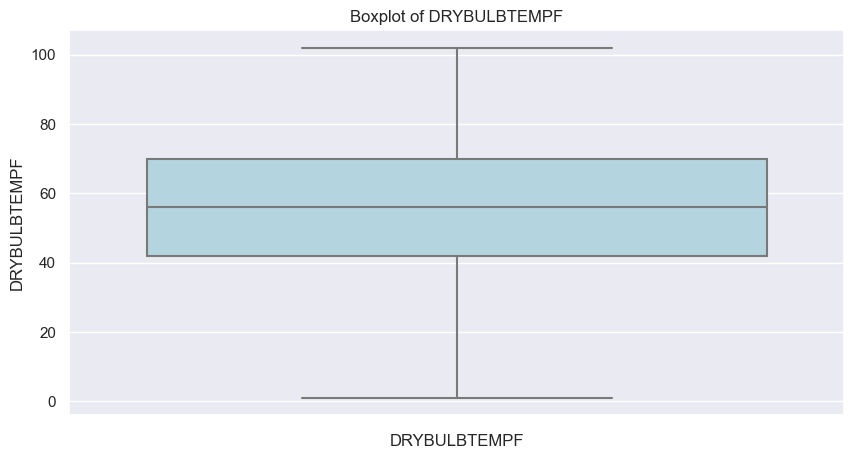

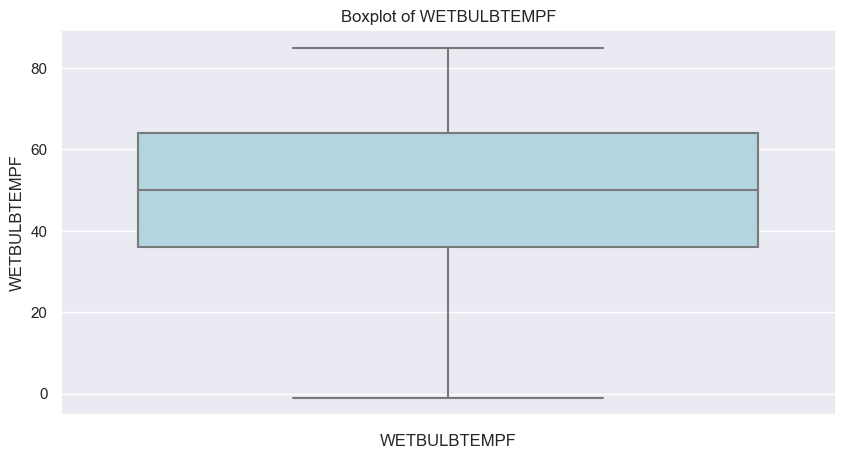

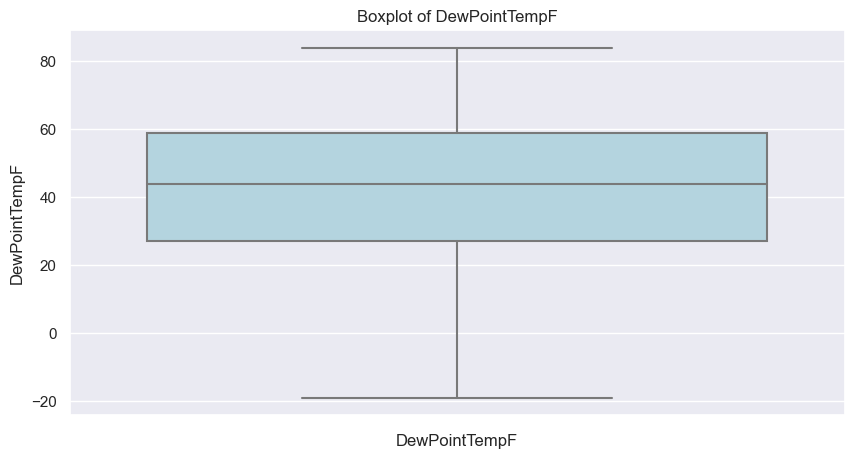

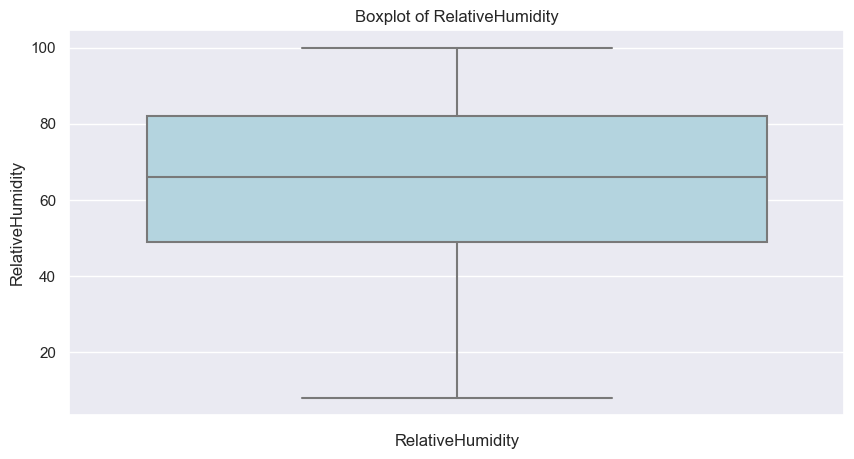

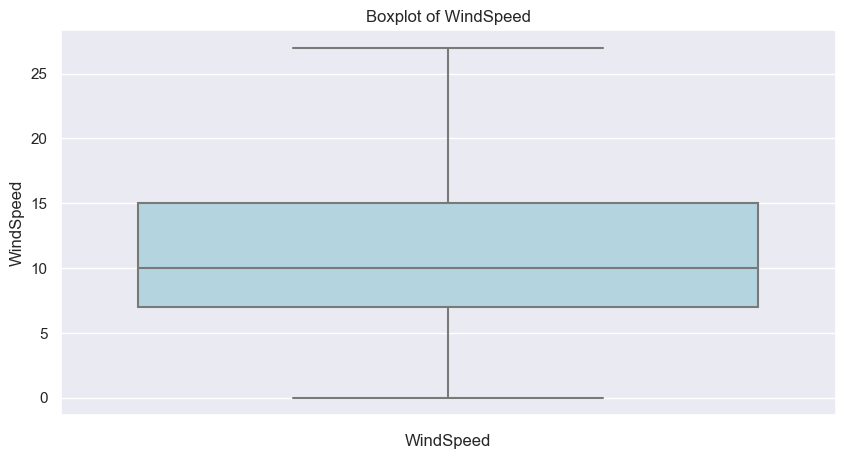

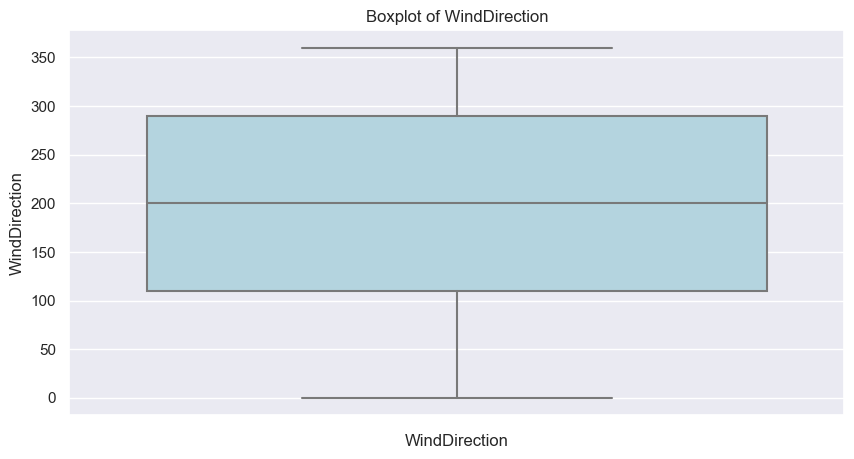

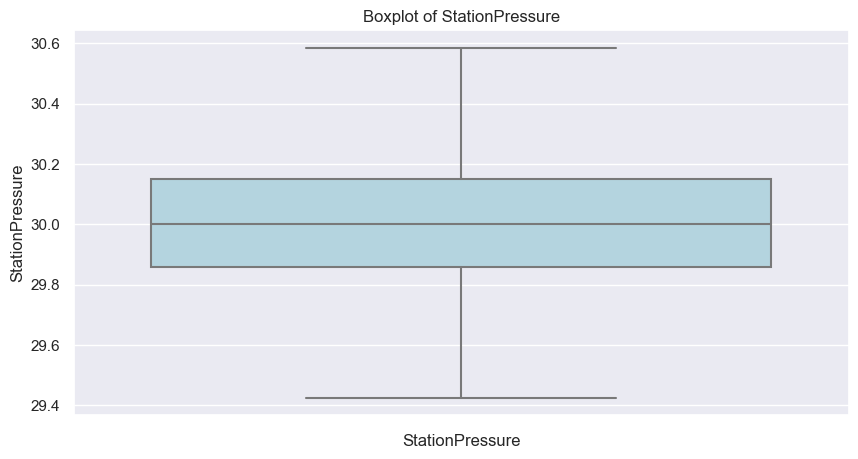

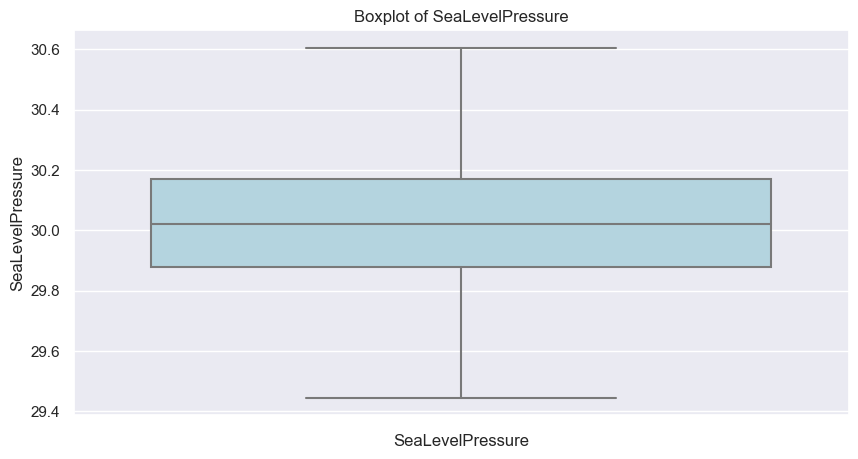

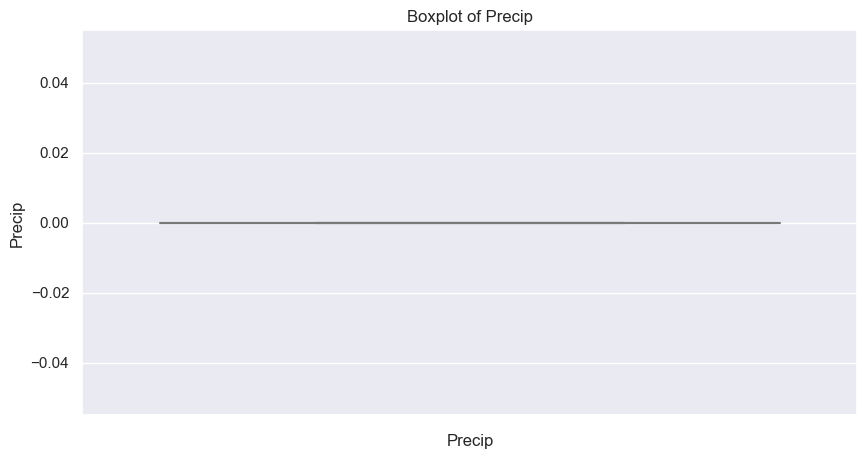

In [16]:
for i in numerical_features.drop('DATE'):
    plt.figure(figsize=(10,5))
    sns.boxplot(y=df[i], color='lightblue')
    plt.title(f'Boxplot of {i}')
    plt.xlabel(i)
    plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_features.drop('DATE')])
scaled_data

array([[-1.28522741, -1.07074102, -0.58351851, ..., -0.15909086,
        -0.16195571,  0.        ],
       [-1.28522741, -1.00894686, -0.53244032, ..., -0.15909086,
        -0.16195571,  0.        ],
       [-1.28522741, -1.00894686, -0.53244032, ..., -0.15909086,
        -0.16195571,  0.        ],
       ...,
       [ 0.89940651,  1.27743702,  1.40853103, ...,  0.05960508,
         0.05756007,  0.        ],
       [ 0.95689687,  1.33923117,  1.40853103, ..., -0.0278733 ,
        -0.03024624,  0.        ],
       [ 0.95689687,  1.33923117,  1.45960923, ...,  0.01586589,
         0.01365691,  0.        ]])

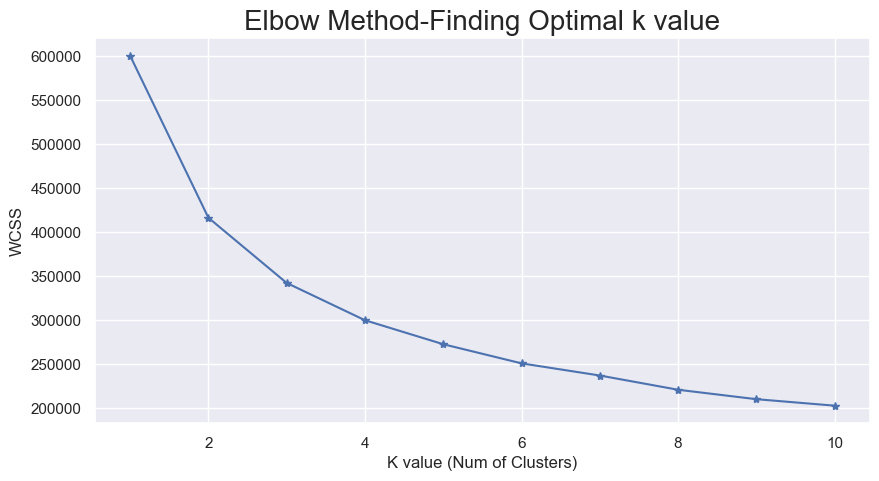

In [19]:
wcss = {}
plt.figure(figsize=(10,5))
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss[i] = kmeans.inertia_
plt.plot(range(1,11),wcss.values(), marker='*')
plt.title('Elbow Method-Finding Optimal k value', fontsize =20)
plt.xlabel('K value (Num of Clusters)')
plt.ylabel('WCSS')
plt.show()


In [27]:
df.head()

,DATE,VISIBILITY,DRYBULBTEMPF,WETBULBTEMPF,DewPointTempF,RelativeHumidity,WindSpeed,WindDirection,StationPressure,SeaLevelPressure,Precip,Cluster
0,2010-01-01 00:51:00,6.0,33.0,32.0,31.0,92.0,0.0,0.0,29.97,29.99,0.0,0
1,2010-01-01 01:51:00,6.0,33.0,33.0,32.0,96.0,0.0,0.0,29.97,29.99,0.0,0
2,2010-01-01 02:51:00,5.0,33.0,33.0,32.0,96.0,0.0,0.0,29.97,29.99,0.0,0
3,2010-01-01 03:51:00,5.0,33.0,33.0,32.0,96.0,0.0,0.0,29.95,29.97,0.0,0
4,2010-01-01 04:51:00,5.0,33.0,32.0,31.0,92.0,0.0,0.0,29.93,29.96,0.0,0


In [29]:
from kneed import KneeLocator

def select_no_of_clusters(dataframe):

    wcss=[] # initializing an empty list
    try:
        for i in range (1,11):
            kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42) # initializing the KMeans object
            kmeans.fit(dataframe) # fitting the data to the KMeans Algorithm
            wcss.append(kmeans.inertia_)
        kn = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
        print('The optimum number of clusters is: '+str(kn.knee)+' . Exited the elbow_plot method of the KMeansClustering class')
        return kn.knee
    except Exception as e:
        print(e)

no_of_clusters = select_no_of_clusters(df.drop('DATE', axis=1))
print("no of clusters is", no_of_clusters)
kmeans = KMeans(n_clusters=no_of_clusters)
kmeans.fit(df.drop('DATE', axis=1))
labels = kmeans.predict(df.drop('DATE', axis=1))
df['Cluster'] = labels

The optimum number of clusters is: 3 . Exited the elbow_plot method of the KMeansClustering class
no of clusters is 3


In [30]:
df['Cluster'].value_counts()

Cluster
2    28907
0    27028
1    19148
Name: count, dtype: int64

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df.drop(columns=['DATE'] , axis=1), test_size=0.2)

X_train = train_set.drop(columns=['VISIBILITY', 'Cluster'])
y_train = train_set[['VISIBILITY']]
X_test = test_set.drop(columns=['VISIBILITY', 'Cluster'])
y_test = test_set[['VISIBILITY']]

preprocessor = StandardScaler()
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [34]:
!python -m pip install dask distributed --upgrade


  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 6.7 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 3.6 MB/s eta 0:00:01
   ----------------------------------- ---- 1.3/1.5 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 0.8/1.0 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 1.3 MB/s  0:00:00
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)

   --- ------------------------------------  1/13 [zipp]
   ------ ---------------------------------  2/13 [zict]
   ------ ------------------

In [35]:
import dask.distributed as distributed

cluster = distributed.LocalCluster()
client = distributed.Client(cluster)
client.restart()



#let's import the models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from xgboost.sklearn import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score



models = {}
models['linear_regression'] = LinearRegression()
models['ridge_regression'] = Ridge()
models['lasso_regression'] = Lasso()
models['elasticnet'] = ElasticNet()
models['xgboost_regressor'] = XGBRegressor()
models['decision_tree_regressor'] = DecisionTreeRegressor()
models['random_forest_regressor'] = RandomForestRegressor()

def select_best_model(models = models, x_train = X_train, y_train = y_train, x_test = X_test, y_test = y_test):
    
    models_details = []
    for model_name, model in models.items():
        model_detail = {}
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        model_score = r2_score(y_test, y_pred)
        model_detail['model_name'] = model_name
        model_detail['model_score'] = model_score
        print("%s model is trained" % model_name)

        models_details.append(model_detail)

    return models_details


models_details = select_best_model()
models_details
        




2025-11-08 17:22:43,581 - distributed.nanny - WARNING - Restarting worker
2025-11-08 17:22:43,587 - distributed.nanny - WARNING - Restarting worker
2025-11-08 17:22:43,605 - distributed.nanny - WARNING - Restarting worker
2025-11-08 17:22:43,621 - distributed.nanny - WARNING - Restarting worker


linear_regression model is trained
ridge_regression model is trained
lasso_regression model is trained
elasticnet model is trained
[17:22:45] WARNING: C:/Jenkins/workspace/xgboost-win64_release_0.90/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
xgboost_regressor model is trained
decision_tree_regressor model is trained
random_forest_regressor model is trained


[{'model_name': 'linear_regression', 'model_score': 0.3473755971991498},
 {'model_name': 'ridge_regression', 'model_score': 0.3473851309468201},
 {'model_name': 'lasso_regression', 'model_score': 0.012457837013952755},
 {'model_name': 'elasticnet', 'model_score': 0.12171816935667257},
 {'model_name': 'xgboost_regressor', 'model_score': 0.5460062026977539},
 {'model_name': 'decision_tree_regressor', 'model_score': 0.2793388479763954},
 {'model_name': 'random_forest_regressor', 'model_score': 0.596348663532855}]

In [48]:
#checking the current working directory and files
import os
os.getcwd()


'c:\\Users\\happy\\climate ml proj'

In [51]:
# root path
import sys
sys.path.append("..")
# import utils
from src.utils.utils import MainUtils

import os
utils = MainUtils()
rf_grid = utils.read_yaml_file("config/model.yaml")['model_selection']['model']['Random Forest Regression']['search_param_grid']
rf_grid

{'n_estimators': [50, 100, 130],
 'max_depth': [10, 20, 30],
 'min_samples_split': [2, 6, 10],
 'bootstrap': [True, False]}

In [ ]:
import joblib
import traceback
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

try:
    with joblib.parallel_backend('dask'):
        model_grid = GridSearchCV(RandomForestRegressor(), rf_grid, cv=2, n_jobs=-1, verbose=3)
        model_grid.fit(X_train, y_train.values.ravel())   # use .ravel() to ensure 1-D target
    print("GridSearch finished. best_score_:", model_grid.best_score_)
except Exception:
    traceback.print_exc()

Fitting 2 folds for each of 54 candidates, totalling 108 fits
